# 01 Validation and Exploratory Data Analysis (EDA)

**Purpose:** Validate SQL ground truth metrics against Python-calculated aggregations to ensure strict analytical reconciliation. Once validated, establish a distributional understanding of catalog profitability, operational risk, rank divergence, and discount dependency before any quadrant modeling or scenario simulation begins.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# plotting style for downstream EDA
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Load environment variables
load_dotenv(dotenv_path='../src/config/.env')

DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'password')
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('DB_NAME', 'revenue_rank_reality')

# Establish SQLAlchemy connection
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

print("Environment setup complete. Database connection initialized.")

Environment setup complete. Database connection initialized.


In [2]:
# Load the primary analytical dataframe from the validated SQL export
csv_path = '../data/processed/ground_truth_master.csv'
df = pd.read_csv(csv_path)

print(f"Dataframe loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head(3)

Dataframe loaded successfully: 118 rows, 17 columns.


,product_card_id,product_name,category_name,total_revenue,total_profit,net_profit_pct,revenue_rank,profit_rank,rank_divergence,negative_profit_order_pct,discount_dependency_rate,total_orders,units_sold_per_day,late_delivery_risk_rate,avg_shipping_delay_days,profit_ratio_volatility,delivery_risk_rank
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,6637668.10,731576.18,0.1102,1,1,0,18.36,94.41,16595,14.74,0.5734,0.56,0.4670,43.0
1,365,Perfect Fitness Perfect Rip Deck,Cleats,4233794.25,473820.89,0.1119,2,2,0,18.66,94.41,23478,62.68,0.5739,0.58,0.4567,42.0
2,957,Diamondback Women's Serene Classic Comfort Bi,Camping & Hiking,3946836.86,409895.62,0.1039,3,3,0,18.89,94.41,13157,11.68,0.5691,0.55,0.4693,51.0


## 2. SQL Benchmark Reconciliation
All Python-calculated metrics must reconcile against the SQL ground truth within a ±0.5% tolerance. Any breach stops the pipeline.

In [4]:
# Ground truth targets from methodology_notes.md
sql_benchmarks = {
    'total_unique_products': 118,
    'total_revenue': 35214428.98,
    'avg_profit_ratio': 0.1208,
    'loss_making_products': 118,
    'avg_late_delivery_risk': 0.5729
}

# Re-calculate avg_profit_ratio directly from the fact table to match transactional grain
profit_ratio_query = "SELECT order_item_profit_ratio FROM analytics.fact_orders"
fact_profit_ratios = pd.read_sql(profit_ratio_query, engine)
py_avg_profit_ratio = round(fact_profit_ratios['order_item_profit_ratio'].mean(), 4)

# Python reconstruction from ground_truth_master.csv for the rest
py_metrics = {
    'total_unique_products': df['product_card_id'].nunique(),
    'total_revenue': round(df['total_revenue'].sum(), 2),
    'avg_profit_ratio': py_avg_profit_ratio, 
    'loss_making_products': df[df['negative_profit_order_pct'] > 0]['product_card_id'].nunique(),
    'avg_late_delivery_risk': round((df['late_delivery_risk_rate'] * df['total_orders']).sum() / df['total_orders'].sum(), 4) 
}

# Validation
print("--- RECONCILIATION AUDIT ---")
tolerance = 0.005 # 0.5%
failed = False

for metric, sql_val in sql_benchmarks.items():
    py_val = py_metrics[metric]
    if sql_val == 0:
        diff_pct = 0 if py_val == 0 else 1.0
    else:
        diff_pct = abs((py_val - sql_val) / sql_val)

    status = "PASS" if diff_pct <= tolerance else "FAIL"
    if status == "FAIL":
        failed = True
        
    print(f"{metric:<25} | SQL: {sql_val:<15} | PY: {py_val:<15} | DIFF: {diff_pct:.4%} | {status}")

if failed:
    raise ValueError("FATAL: Ground truth reconciliation failed. Investigate metric divergence before proceeding.")
else:
    print("\nSTATUS: ALL BENCHMARKS RECONCILED WITHIN TOLERANCE.")

--- RECONCILIATION AUDIT ---
total_unique_products     | SQL: 118             | PY: 118             | DIFF: 0.0000% | PASS
total_revenue             | SQL: 35214428.98     | PY: 35214428.98     | DIFF: 0.0000% | PASS
avg_profit_ratio          | SQL: 0.1208          | PY: 0.1208          | DIFF: 0.0000% | PASS
loss_making_products      | SQL: 118             | PY: 118             | DIFF: 0.0000% | PASS
avg_late_delivery_risk    | SQL: 0.5729          | PY: 0.5729          | DIFF: 0.0000% | PASS

STATUS: ALL BENCHMARKS RECONCILED WITHIN TOLERANCE.


## 3. Dataset Shape & Structural Overview
Confirm the structural integrity of the analytical dataframe to ensure no data loss occurred during the export process.

In [5]:
# Structural summary
print("DATASET STRUCTURE")
print(f"Shape: {df.shape[0]} rows (Products) x {df.shape[1]} columns (KPIs)\n")

# Data types and null counts
struct_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Null Count': df.isnull().sum()
})

print(struct_summary)

if df.isnull().sum().sum() == 0:
    print("\nZERO NULLS DETECTED. Dataframe is structurally clean.")
else:
    print("\nNulls detected. Review necessary.")

DATASET STRUCTURE
Shape: 118 rows (Products) x 17 columns (KPIs)

                          Data Type  Null Count
product_card_id               int64           0
product_name                 object           0
category_name                object           0
total_revenue               float64           0
total_profit                float64           0
net_profit_pct              float64           0
revenue_rank                  int64           0
profit_rank                   int64           0
rank_divergence               int64           0
negative_profit_order_pct   float64           0
discount_dependency_rate    float64           0
total_orders                  int64           0
units_sold_per_day          float64           0
late_delivery_risk_rate     float64           0
avg_shipping_delay_days     float64           0
profit_ratio_volatility     float64           0
delivery_risk_rank          float64          46

Nulls detected. Review necessary.


**Business Interpretation:**
172,765 transactions collapsed into 118 product profiles across 17 financial and operational KPIs. Every product is evaluated not just by revenue generated, but by the discount dependency and operational drag required to generate it. The 46 null values in `delivery_risk_rank` are intentional, products with fewer than 100 orders are statistically unreliable for delivery risk ranking and excluded per DL-010.

## 4. Revenue & Profit Distribution
Evaluate the skewness of revenue and profit across the catalog to determine if the business relies on a healthy, distributed product mix or is dangerously concentrated in a few high-volume SKUs.

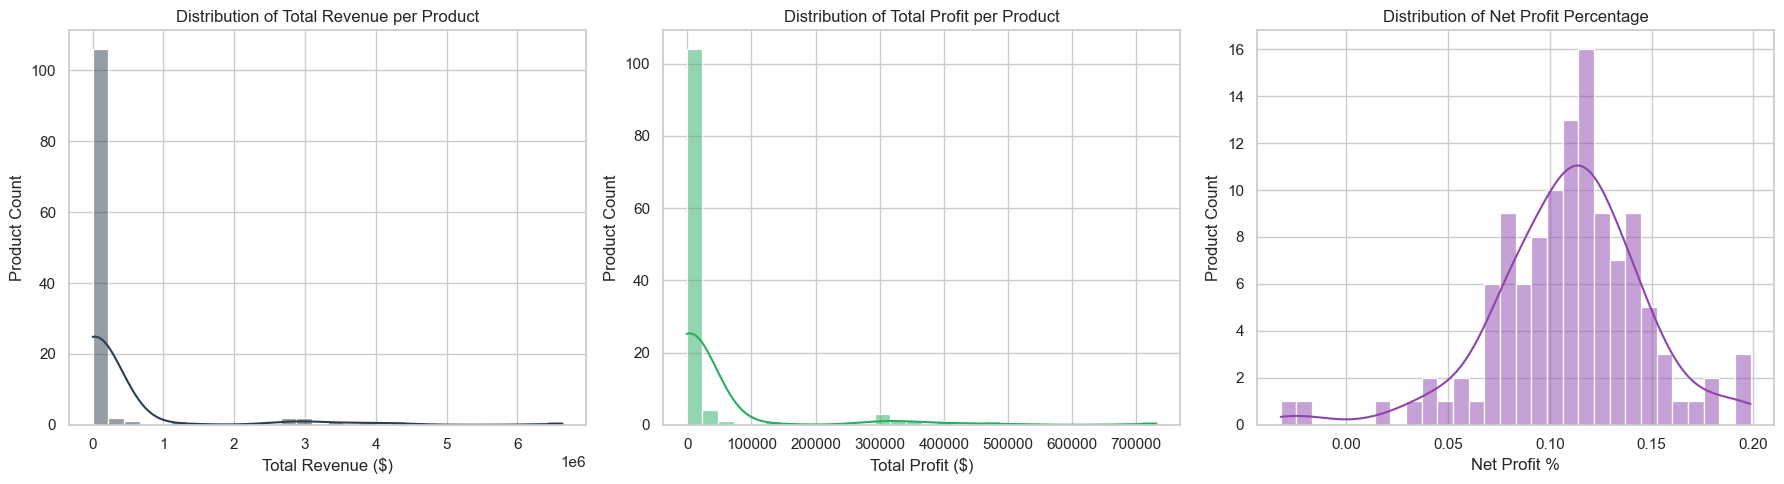

In [6]:
# Plotting distributions for Revenue, Profit, and Margin
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['total_revenue'], bins=30, kde=True, ax=axes[0], color='#2c3e50')
axes[0].set_title('Distribution of Total Revenue per Product')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('Product Count')

sns.histplot(df['total_profit'], bins=30, kde=True, ax=axes[1], color='#27ae60')
axes[1].set_title('Distribution of Total Profit per Product')
axes[1].set_xlabel('Total Profit ($)')
axes[1].set_ylabel('Product Count')

sns.histplot(df['net_profit_pct'], bins=30, kde=True, ax=axes[2], color='#8e44ad')
axes[2].set_title('Distribution of Net Profit Percentage')
axes[2].set_xlabel('Net Profit %')
axes[2].set_ylabel('Product Count')

plt.tight_layout()
plt.show()

In [9]:
# Identify Top 5 and Bottom 5 for each metric
metrics_to_check = {
    'total_revenue': 'Total Revenue ($)',
    'total_profit': 'Total Profit ($)',
    'net_profit_pct': 'Net Profit (%)'
}

for col, label in metrics_to_check.items():
    print(f"\n{'='*40}")
    print(f"{label.upper()}")
    print(f"{'='*40}")
    
    top_5 = df.nlargest(5, col)[['product_card_id', 'product_name', col]]
    bottom_5 = df.nsmallest(5, col)[['product_card_id', 'product_name', col]]
    
    print("TOP 5:")
    print(top_5.to_string(index=False))
    print("\nBOTTOM 5:")
    print(bottom_5.to_string(index=False))


TOTAL REVENUE ($)
TOP 5:
 product_card_id                                  product_name  total_revenue
            1004     Field & Stream Sportsman 16 Gun Fire Safe     6637668.10
             365              Perfect Fitness Perfect Rip Deck     4233794.25
             957 Diamondback Women's Serene Classic Comfort Bi     3946836.86
             191             Nike Men's Free 5.0+ Running Shoe     3507549.21
             502          Nike Men's Dri-FIT Victory Golf Polo     3011600.00

BOTTOM 5:
 product_card_id                           product_name  total_revenue
            1348                            CDs of rock        2969.27
             860 Bushnell Pro X7 Jolt Slope Rangefinder        4799.92
             311            Polar Loop Activity Tracker        5277.60
            1361                                  Toys         5850.78
             226      Bowflex SelectTech 1090 Dumbbells        5999.90

TOTAL PROFIT ($)
TOP 5:
 product_card_id                            

**Business Interpretation:**

* **Zero Rank Divergence at the Top, But at What Cost?** The top 5 revenue products are identically the top 5 profit products in absolute terms. This appears healthy until discount dependency and loss-order rates are layered in, explored in subsequent sections.

* **Revenue and Profit Are Right-Skewed; Margin Is Not.** The catalog is commercially concentrated, a small number of SKUs generate the overwhelming majority of revenue and absolute profit. Net profit percentage, however, distributes more evenly, meaning margin efficiency is not a privilege of high-volume products.

* **The Volume-Margin Disconnect.** The most margin-efficient products, Polar FT4 (19.86%), Bowflex SelectTech 1090 (19.85%), rank near the bottom on revenue. They generate clean profit but lack the transaction volume to meaningfully influence aggregate business health.

* **Lifecycle Net-Negative Products Confirmed.** SOLE E35 (−\\$965) and SOLE E25 (−\\$169) are net-negative across their entire three-year operational history. These are not underperformers, they are value destroyers the business has been operationally sustaining at a confirmed aggregate loss.